# Live demo - Predicting metabolic cost during human-in-the-loop optimisation
**Team 13** - Manav Dewangan (PES2UG24CS262), Lakshmi Narasimha Moorty Perepa (PES2UG24CS248)

Metabolic cost is slow, noisy and needs a lab mask to measure. Can we predict it from wearable signals (gait + EMG) recorded while an exoskeleton controller is being optimised?

Run the cells top to bottom. Change `SUBJECT` / `FEATURE_SET` below to answer panel questions live.

In [1]:
SUBJECT = 'S1'        # 'S1' or 'S2'
FEATURE_SET = 'all'   # 'all', 'step_emg', 'step', 'emg'

In [2]:
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.baselines import make_constant, make_lasso
from src.config import NOISE_FLOOR_MSE, TABLES_DIR
from src.data import load_all
from src.eda import plot_metabolic_by_day
from src.evaluation import cross_validate_model
from src.models import make_nn

## Step 1 - The data: 5 walking days x 36 controller settings per subject

S1: 180 samples, 29 features (all)


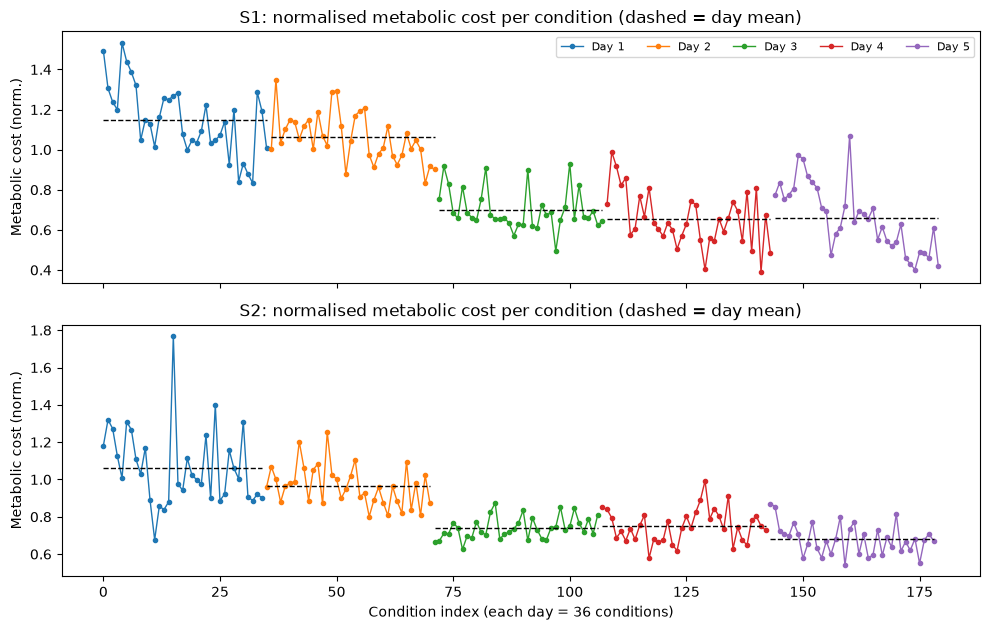

In [3]:
datasets = load_all()
data = datasets[SUBJECT].subset(FEATURE_SET)
print(f'{SUBJECT}: {data.n_samples} samples, {data.X.shape[1]} features ({FEATURE_SET})')
plot_metabolic_by_day(datasets)
plt.show()

## Step 2 - Train live, testing on a day the model has never seen

In [4]:
models = {
    'constant': make_constant(),
    'lasso': make_lasso(),
    'neural net (3 tanh units)': make_nn(hidden_units=3, alpha=1.0),
}
results = {}
for name, model in models.items():
    t = time.time()
    results[name] = {p: cross_validate_model(model, data, p) for p in ['kfold', 'lodo']}
    print(f'{name:28s} random 5-fold MSE = {results[name]["kfold"].mse:.4f} | '
          f'leave-one-day-out MSE = {results[name]["lodo"].mse:.4f}  ({time.time() - t:.1f}s)')
print(f'noise floor of metabolic measurement = {NOISE_FLOOR_MSE}')

constant                     random 5-fold MSE = 0.0666 | leave-one-day-out MSE = 0.0917  (6.3s)


lasso                        random 5-fold MSE = 0.0091 | leave-one-day-out MSE = 0.0205  (0.4s)


neural net (3 tanh units)    random 5-fold MSE = 0.0112 | leave-one-day-out MSE = 0.0317  (0.2s)
noise floor of metabolic measurement = 0.0025


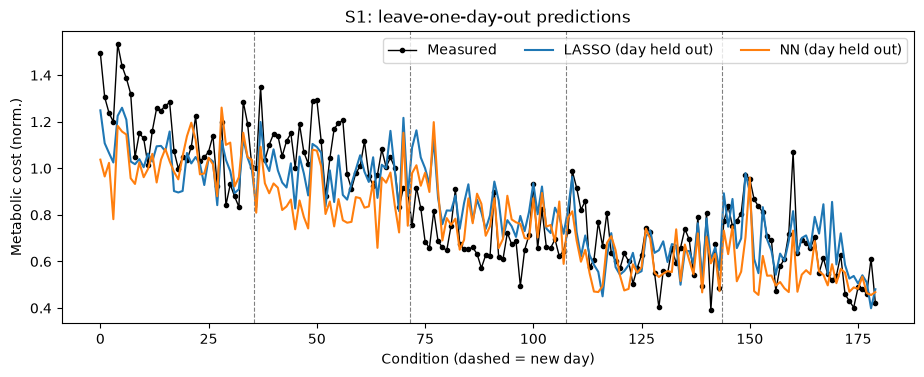

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(data.y, 'k.-', lw=1, label='Measured')
ax.plot(results['lasso']['lodo'].y_pred, label='LASSO (day held out)')
ax.plot(results['neural net (3 tanh units)']['lodo'].y_pred, label='NN (day held out)')
for b in np.flatnonzero(np.diff(data.day)) + 0.5:
    ax.axvline(b, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Condition (dashed = new day)'); ax.set_ylabel('Metabolic cost (norm.)')
ax.legend(ncol=3); ax.set_title(f'{SUBJECT}: leave-one-day-out predictions')
plt.show()

## Step 3 - Full results (pre-computed by `python -m scripts.run_experiments`)

In [6]:
comparison = pd.read_csv(TABLES_DIR / 'model_comparison.csv')
table = comparison[comparison.feature_set == FEATURE_SET].pivot_table(
    index=['subject', 'model'], columns='protocol', values=['mse', 'paper_mse'])
table.round(4)

mse         paper_mse
protocol           kfold    lodo     kfold
subject model                             
S1      constant  0.0666  0.0917    0.0657
        lasso     0.0091  0.0205    0.0089
        nn        0.0101  0.0223    0.0089
        ridge     0.0086  0.0143       NaN
S2      constant  0.0362  0.0478    0.0465
        lasso     0.0135  0.0309    0.0176
        nn        0.0150  0.0315    0.0301
        ridge     0.0146  0.0358       NaN

## Take-aways
* With the paper's random k-fold protocol we reproduce its accuracy (MSE about 0.009 for S1).
* Holding out a whole day - the realistic use case - roughly doubles the error: day-to-day adaptation is the main obstacle, not model capacity.
* Simple regularised linear models match or beat the shallow neural network on this small dataset.